# SMA-GAN

In [ ]:
# SMA-GAN - Self-Attention cGAN (SAGAN-style) for Art Restoration
# - No U-Net skips
# - No L1 pixel loss (not pix2pix)
# - Spectral Norm + Hinge loss
# - Projection Discriminator conditioned on damaged tiles

import os, glob, math
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


In [ ]:
# Config
IMG_SIZE = 128
CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 20

LR_G = 2e-4
LR_D = 2e-4
BETAS = (0.0, 0.9)      # common for hinge GANs
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")


DATA_ROOT = r"../../TilingAlgorithm/tiledset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train_indexed_images")
TEST_DIR  = os.path.join(DATA_ROOT, "test_indexed_images") if os.path.exists(os.path.join(DATA_ROOT, "test_indexed_images")) else None

print("Device:", DEVICE)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

'\n# Root like your structure:\n# root/train_indexed_images/damaged/<sub>/*.png\n# root/train_indexed_images/undamaged/<sub>/*.png\nDATA_ROOT = r"/Users/martashkreli/Desktop/tiledsets"\nTRAIN_DIR = os.path.join(DATA_ROOT, "train_indexed_images")\nTEST_DIR  = os.path.join(DATA_ROOT, "test_indexed_images") if os.path.exists(os.path.join(DATA_ROOT, "test_indexed_images")) else None\n\nprint("Device:", DEVICE)\nprint("TRAIN_DIR:", TRAIN_DIR)\nprint("TEST_DIR:", TEST_DIR)\n'

In [ ]:
# Utilities
def denorm(t):
    # [-1,1] -> [0,1]
    return (t * 0.5 + 0.5).clamp(0, 1)

def show_triplet(damaged, fake, real, title=""):
    damaged = denorm(damaged.detach().cpu())
    fake    = denorm(fake.detach().cpu())
    real    = denorm(real.detach().cpu())

    def to_img(x):
        return x.permute(1,2,0).numpy()

    plt.figure(figsize=(10,4))
    plt.suptitle(title)
    plt.subplot(1,3,1); plt.imshow(to_img(damaged)); plt.title("Damaged"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(to_img(fake));    plt.title("Generated"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(to_img(real));    plt.title("GT"); plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# Dataset with texture scores (for weighted sampling)
class ArtRestorationDataset(Dataset):
    def _is_blank(self, path, whiteness=240, frac=0.98):
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        white = (arr[...,0] >= whiteness) & (arr[...,1] >= whiteness) & (arr[...,2] >= whiteness)
        return white.mean() >= frac

    def _content_score(self, pil_img):
    # Convert to numpy
        rgb = np.array(pil_img.convert("RGB"), dtype=np.float32)  # 0..255
        gray = np.array(pil_img.convert("L"), dtype=np.float32)

        H, W = gray.shape

        # Edge density (captures shapes: eyes, mouth, hands, folds)
        gx = np.abs(gray[:, 1:] - gray[:, :-1])
        gy = np.abs(gray[1:, :] - gray[:-1, :])
        edge_strength = (gx.mean() + gy.mean())
        edge_density = ((gx > 12).mean() + (gy > 12).mean()) / 2.0  # thresholded edges

        # Entropy (information content) – but not enough alone
        hist = np.histogram(gray, bins=64, range=(0, 255), density=True)[0]
        hist = hist[hist > 1e-12]
        entropy = float(-np.sum(hist * np.log(hist)))

        # Colorfulness (faces/clothes often increase this vs flat backgrounds)
        r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
        rg = r - g
        yb = 0.5 * (r + g) - b
        colorfulness = float(np.sqrt(rg.var() + yb.var()) + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))

        #“Skin-likeliness” heuristic (helps pick faces/hands; not perfect)
        # Simple RGB rule-of-thumb for skin-ish pixels:
        skin = (
            (r > 95) & (g > 40) & (b > 20) &
            ((r - g) > 15) & (r > b) &
            (np.abs(r - b) > 15)
        )
        skin_frac = float(skin.mean())

        # Border penalty (avoid frames/edges dominating)
        m = int(0.08 * min(H, W))  # 8% border
        if m >= 2:
            border = np.concatenate([
                gray[:m, :].ravel(), gray[-m:, :].ravel(),
                gray[:, :m].ravel(), gray[:, -m:].ravel()
            ])
            center = gray[m:-m, m:-m].ravel()
            border_var = border.var()
            center_var = center.var() if center.size else gray.var()
            border_penalty = float(max(0.0, border_var - center_var))  # penalize “border busier than center”
        else:
            border_penalty = 0.0

        # Final score (tune weights if needed)
        score = (
            3.0 * edge_density +
            0.02 * edge_strength +
            0.6 * entropy +
            0.002 * colorfulness +
            8.0 * skin_frac -
            0.001 * border_penalty
        )
        return float(score)

    def __init__(self, root_dir, transform=None, img_ext="png", strict_pairs=False):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.strict_pairs = strict_pairs

        damaged_glob = str(self.root_dir / "damaged" / "*" / f"*.{img_ext}")
        damaged_paths = sorted(glob.glob(damaged_glob))

        self.damaged_paths = []
        self.undamaged_paths = []
        self.scores = []

        for p in damaged_paths:
            dmg = Path(p)
            parts = list(dmg.parts)
            try:
                i = parts.index("damaged")
                parts[i] = "undamaged"
                undmg = Path(*parts)
            except ValueError:
                undmg = None

            if undmg is None or not undmg.exists():
                if self.strict_pairs:
                    raise FileNotFoundError(f"Missing matching undamaged for {dmg}")
                continue

            if self._is_blank(dmg) or self._is_blank(undmg):
                continue

            img_d = Image.open(dmg).convert("RGB")
            img_u = Image.open(undmg).convert("RGB")
            score = max(self._content_score(img_d), self._content_score(img_u))

            self.damaged_paths.append(str(dmg))
            self.undamaged_paths.append(str(undmg))
            self.scores.append(score)

        if len(self.damaged_paths) == 0:
            raise RuntimeError(f"No valid pairs found in {root_dir}. Check folder structure.")

    def __len__(self):
        return len(self.damaged_paths)

    def __getitem__(self, idx):
        dmg_path = self.damaged_paths[idx]
        und_path = self.undamaged_paths[idx]
        try:
            d = Image.open(dmg_path).convert("RGB")
            r = Image.open(und_path).convert("RGB")
            if self.transform:
                d = self.transform(d)
                r = self.transform(r)
            return d, r, dmg_path, und_path
        except Exception as e:
            print("Load error:", e, dmg_path, und_path)
            z = torch.zeros(3, IMG_SIZE, IMG_SIZE)
            return z, z, dmg_path, und_path


In [ ]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3),  # -> [-1,1]
])

# DataLoader settings 
NUM_WORKERS = 0
PIN_MEMORY = (DEVICE == "cuda")

# Datasets
train_ds = ArtRestorationDataset(TRAIN_DIR, transform=transform)

test_ds = None
if TEST_DIR is not None and os.path.isdir(TEST_DIR):
    test_ds = ArtRestorationDataset(TEST_DIR, transform=transform)

# Weighted sampler for training
scores = np.array(train_ds.scores, dtype=np.float32)
scores_clipped = np.clip(scores, a_min=0.0, a_max=None)
weights = np.log1p(scores_clipped)
weights = weights / (weights.mean() + 1e-8)

sampler = WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True
)


# Loaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True
)

test_loader = None
test_loader_vis = None

if test_ds is not None:
    # deterministic test loader (optional)
    test_loader = DataLoader(
        test_ds,
        batch_size=4,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    # shuffled visualization loader (Option A)
    test_loader_vis = DataLoader(
        test_ds,
        batch_size=32,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

# Prints (no NameErrors)
print("Train pairs:", len(train_ds))
print("Test pairs:", len(test_ds) if test_ds is not None else 0)

Train pairs: 415
Test pairs: 232


In [ ]:
# Self-Attention block (SAGAN style)
class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.query = nn.utils.spectral_norm(nn.Conv2d(ch, ch // 8, 1))
        self.key   = nn.utils.spectral_norm(nn.Conv2d(ch, ch // 8, 1))
        self.value = nn.utils.spectral_norm(nn.Conv2d(ch, ch, 1))
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        b, c, h, w = x.shape
        n = h * w
        q = self.query(x).view(b, -1, n).permute(0, 2, 1)  # b,n,c'
        k = self.key(x).view(b, -1, n)                     # b,c',n
        attn = self.softmax(torch.bmm(q, k))                # b,n,n
        v = self.value(x).view(b, c, n)                     # b,c,n
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(b, c, h, w)
        return x + self.gamma * out


In [ ]:
# Generator: Encoder-Res-Decoder with attention
# Conditioned on damaged image; optional noise injection.
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.c2 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.n1 = nn.InstanceNorm2d(ch, affine=True)
        self.n2 = nn.InstanceNorm2d(ch, affine=True)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        y = self.act(self.n1(self.c1(x)))
        y = self.n2(self.c2(y))
        return self.act(x + y)

class SMAGenerator(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=64, use_noise=True):
        super().__init__()
        self.use_noise = use_noise

        # Encoder
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, base, 4, 2, 1), nn.ReLU(True))          # 64x64
        self.e2 = nn.Sequential(nn.Conv2d(base, base*2, 4, 2, 1), nn.InstanceNorm2d(base*2, affine=True), nn.ReLU(True))  # 32x32
        self.e3 = nn.Sequential(nn.Conv2d(base*2, base*4, 4, 2, 1), nn.InstanceNorm2d(base*4, affine=True), nn.ReLU(True)) # 16x16
        self.e4 = nn.Sequential(nn.Conv2d(base*4, base*8, 4, 2, 1), nn.InstanceNorm2d(base*8, affine=True), nn.ReLU(True)) # 8x8

        # Attention at 16x16 and/or 32x32 features (global context)
        self.att16 = SelfAttention(base*4)
        self.att32 = SelfAttention(base*2)

        # Bottleneck residuals
        self.res = nn.Sequential(*[ResBlock(base*8) for _ in range(4)])

        # Decoder
        self.d1 = nn.Sequential(nn.ConvTranspose2d(base*8, base*4, 4, 2, 1),
                                nn.InstanceNorm2d(base*4, affine=True), nn.ReLU(True))  # 16x16
        self.d2 = nn.Sequential(nn.ConvTranspose2d(base*4, base*2, 4, 2, 1),
                                nn.InstanceNorm2d(base*2, affine=True), nn.ReLU(True))  # 32x32
        self.d3 = nn.Sequential(nn.ConvTranspose2d(base*2, base, 4, 2, 1),
                                nn.InstanceNorm2d(base, affine=True), nn.ReLU(True))    # 64x64
        self.d4 = nn.Sequential(nn.ConvTranspose2d(base, out_ch, 4, 2, 1),
                                nn.Tanh())                                               # 128x128

    def forward(self, x):
        # optional tiny noise for diversity (can help avoid over-smoothing)
        if self.use_noise:
            x = x + 0.03 * torch.randn_like(x)

        f1 = self.e1(x)
        f2 = self.e2(f1)
        f2 = self.att32(f2)
        f3 = self.e3(f2)
        f3 = self.att16(f3)
        f4 = self.e4(f3)

        b = self.res(f4)

        y = self.d1(b)
        y = self.d2(y)
        y = self.d3(y)
        y = self.d4(y)
        return y


In [ ]:
# Projection Discriminator conditioned on damaged image
# D(x, y): y = real/fake restored, x = damaged condition
class SMADiscriminator(nn.Module):
    def __init__(self, img_ch=3, cond_ch=3, base=64):
        super().__init__()

        # Image path (real/fake restored)
        def snconv(in_c, out_c, k=4, s=2, p=1):
            return nn.utils.spectral_norm(nn.Conv2d(in_c, out_c, k, s, p))

        self.f1 = nn.Sequential(snconv(img_ch, base), nn.LeakyReLU(0.2, True))         # 64x64
        self.f2 = nn.Sequential(snconv(base, base*2), nn.LeakyReLU(0.2, True))        # 32x32
        self.att = SelfAttention(base*2)                                              # 32x32 attention
        self.f3 = nn.Sequential(snconv(base*2, base*4), nn.LeakyReLU(0.2, True))      # 16x16
        self.f4 = nn.Sequential(snconv(base*4, base*8), nn.LeakyReLU(0.2, True))      # 8x8
        self.f5 = nn.Sequential(snconv(base*8, base*8, k=4, s=2, p=1), nn.LeakyReLU(0.2, True))  # 4x4

        # Condition encoder to a vector
        self.cond_enc = nn.Sequential(
            nn.Conv2d(cond_ch, base, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base, base*2, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.AdaptiveAvgPool2d(1)  # -> (B, base*4, 1, 1)
        )

        # Final logits
        self.out = nn.utils.spectral_norm(nn.Conv2d(base*8, 1, 4, 1, 0))  # from 4x4 -> 1x1

        # Projection: map image feature vector to same dim as cond vector
        self.proj_img = nn.utils.spectral_norm(nn.Linear(base*8, base*4))

    def forward(self, cond_x, img_y, return_features=False):
        # img_y features
        h1 = self.f1(img_y)
        h2 = self.f2(h1)
        h2 = self.att(h2)
        h3 = self.f3(h2)
        h4 = self.f4(h3)
        h5 = self.f5(h4)  # B, base*8, 4, 4

        # global pooled image feature
        img_vec = h5.mean(dim=(2,3))  # B, base*8

        # condition vector
        c = self.cond_enc(cond_x).squeeze(-1).squeeze(-1)  # B, base*4

        # unconditional logit
        logit_uncond = self.out(h5).view(-1)  # B

        # projection term
        proj = (self.proj_img(img_vec) * c).sum(dim=1)  # B

        logit = logit_uncond + proj

        if return_features:
            return logit, [h1, h2, h3, h4, h5]
        return logit

In [ ]:
# Losses (Hinge GAN)
def d_hinge_loss(real_logits, fake_logits):
    return (torch.relu(1.0 - real_logits).mean() + torch.relu(1.0 + fake_logits).mean())

def g_hinge_loss(fake_logits):
    return (-fake_logits.mean())

# Optional: feature matching for stability/sharpness (still not pix2pix)
def feature_matching_loss(real_feats, fake_feats):
    loss = 0.0
    for r, f in zip(real_feats, fake_feats):
        loss = loss + (r.mean(dim=0) - f.mean(dim=0)).abs().mean()
    return loss

In [ ]:
# Build models
G = SMAGenerator(use_noise=True).to(DEVICE)
D = SMADiscriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)


In [ ]:
# Visualization: find a textured sample by scanning batches
def show_best_textured(gen, loader, max_batches=50):
    gen.eval()
    best = None
    with torch.no_grad():
        for b, (damaged, real, dp, rp) in enumerate(loader):
            damaged = damaged.to(DEVICE)
            real = real.to(DEVICE)
            fake = gen(damaged)

            # pick the most "textured" tile in this batch by variance
            for j in range(damaged.size(0)):
                v = max(damaged[j].var().item(), real[j].var().item())
                if (best is None) or (v > best[0]):
                    best = (v, damaged[j], fake[j], real[j], dp[j], rp[j])

            if b + 1 >= max_batches:
                break

    v, d, f, r, dp, rp = best
    print("Chosen var:", v)
    print("Damaged:", dp)
    print("GT:", rp)
    show_triplet(d, f, r, title=f"Best textured (var={v:.4f})")
    gen.train()


Starting training...
epoch 1/2 iter 0/25 D 1.334  G 2.982 (adv 0.644, fm 0.234)
epoch 2/2 iter 0/25 D 1.828  G 2.147 (adv 0.995, fm 0.115)

--- VIS epoch 2 ---
Chosen var: 0.795880913734436
Damaged: /content/tiledsets/test_indexed_images/damaged/022/022_4_1.png
GT: /content/tiledsets/test_indexed_images/undamaged/022/022_4_1.png


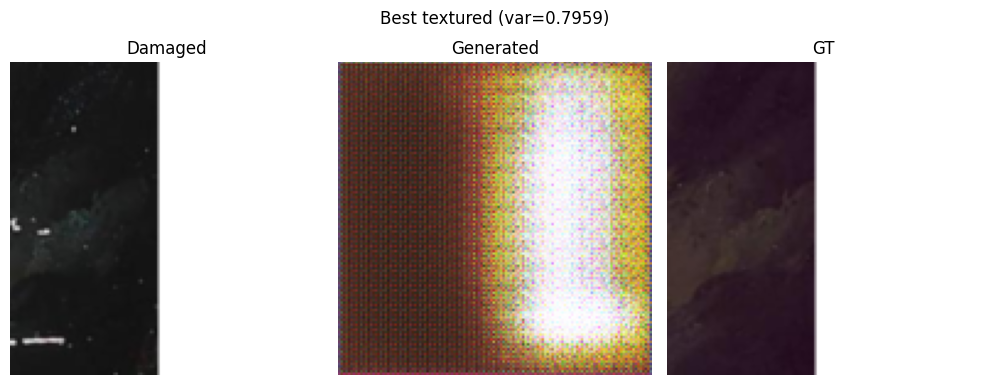

In [ ]:
# Training loop
FM_LAMBDA = 10.0  # feature matching weight (try 0, 5, 10)
PRINT_EVERY = 50
VIS_EVERY_EPOCHS = 2

print("Starting training...")
for epoch in range(EPOCHS):
    for i, (damaged, real, dp, rp) in enumerate(train_loader):
        damaged = damaged.to(DEVICE)
        real = real.to(DEVICE)

        # Train D
        opt_D.zero_grad(set_to_none=True)

        with torch.no_grad():
            fake = G(damaged)

        real_logits, real_feats = D(damaged, real, return_features=True)
        fake_logits, fake_feats = D(damaged, fake, return_features=True)

        loss_D = d_hinge_loss(real_logits, fake_logits)
        loss_D.backward()
        opt_D.step()

        # Train G
        opt_G.zero_grad(set_to_none=True)

        fake = G(damaged)
        fake_logits, fake_feats = D(damaged, fake, return_features=True)

        loss_G_adv = g_hinge_loss(fake_logits)

        # Feature matching (helps avoid collapse/blur without using L1)
        with torch.no_grad():
            _, real_feats_for_fm = D(damaged, real, return_features=True)

        loss_FM = feature_matching_loss(real_feats_for_fm, fake_feats)
        loss_G = loss_G_adv + FM_LAMBDA * loss_FM

        loss_G.backward()
        opt_G.step()

        if i % PRINT_EVERY == 0:
            print(f"epoch {epoch+1}/{EPOCHS} iter {i}/{len(train_loader)} "
                  f"D {loss_D.item():.3f}  G {loss_G.item():.3f} (adv {loss_G_adv.item():.3f}, fm {loss_FM.item():.3f})")

    if (epoch + 1) % VIS_EVERY_EPOCHS == 0:
        print(f"\n--- VIS epoch {epoch+1} ---")
        if test_loader is not None:
            show_best_textured(G, test_loader, max_batches=50)
        else:
            show_best_textured(G, train_loader, max_batches=50)

In [ ]:
# Test & Evaluation

def benchmark_gan_quantitative_robust(gen_model, loader, device):
    """
    Evaluates the Generator model on the test set using PSNR and SSIM metrics.
    Robust to dataloaders returning extra information (like filenames).
    """
    gen_model.eval()
    psnr_scores = []
    ssim_scores = []

    print(f"Starting benchmark on {len(loader.dataset)} test images...")

    with torch.no_grad():
        # Retrieve the whole batch tuple instead of unpacking strictly
        for batch in loader:
            # Extract only the first 2 elements (Input, Target) and ignore the rest (e.g., filenames)
            inputs = batch[0]
            targets = batch[1]

            inputs = inputs.to(device)
            targets = targets.to(device)

            # Generate Fake Images
            fake_imgs = gen_model(inputs)

            # Denormalize: Convert from [-1, 1] range back to [0, 1]
            fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1).cpu().numpy()
            targets_np = (targets * 0.5 + 0.5).cpu().numpy()

            # Calculate metrics for each image in the batch
            batch_size = fake_imgs.shape[0]
            for i in range(batch_size):
                # Permute dimensions: PyTorch (C, H, W) -> Skimage (H, W, C)
                img_pred = np.moveaxis(fake_imgs[i], 0, -1)
                img_true = np.moveaxis(targets_np[i], 0, -1)

                # Calculate PSNR and SSIM
                p = psnr(img_true, img_pred, data_range=1.0)
                s = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)

                psnr_scores.append(p)
                ssim_scores.append(s)

    # Display Results
    print("\n" + "="*30)
    print(f" QUANTITATIVE RESULTS (SMA-GAN)")
    print("="*30)
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB (Higher is better)")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}    (Closer to 1.0 is better)")
    print("="*30)

# Run the benchmark
benchmark_gan_quantitative_robust(G, test_loader, DEVICE)

Starting benchmark on 232 test images...

 QUANTITATIVE RESULTS (SMA-GAN)
Average PSNR: 9.57 dB (Higher is better)
Average SSIM: 0.1650    (Closer to 1.0 is better)
